# Lab Exercise 10: Learning the XOR Boolean Function Using an MLP

## Part 1: Keras Implementation

### 1. Create the Dataset

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define input (X) and output (y) for XOR function
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
y = np.array([[0], [1], [1], [0]], dtype=np.float32)

print("Input (X):")
print(X)
print("\nOutput (y):")
print(y)

Input (X):
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

Output (y):
[[0.]
 [1.]
 [1.]
 [0.]]


The dataset is defined with two inputs and a single output, representing the four possible combinations for the XOR function.

### 2. Build an MLP Model (Keras)

In [ ]:
# Build the MLP model
model = keras.Sequential([
    layers.Input(shape=(2,)), # Input layer with 2 neurons
    layers.Dense(units=4, activation='relu', name='hidden_layer'), # Hidden layer with 4 neurons and ReLU activation
    layers.Dense(units=1, activation='sigmoid', name='output_layer') # Output layer with 1 neuron and sigmoid activation
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

The model consists of an input layer, a hidden layer with 4 ReLU activated neurons, and an output layer with a single sigmoid activated neuron, suitable for binary classification.

### 3. Compile the Model

In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

The model is compiled using the Adam optimizer and Binary Cross-Entropy loss, which are standard choices for binary classification tasks.

### 4. Train the Model

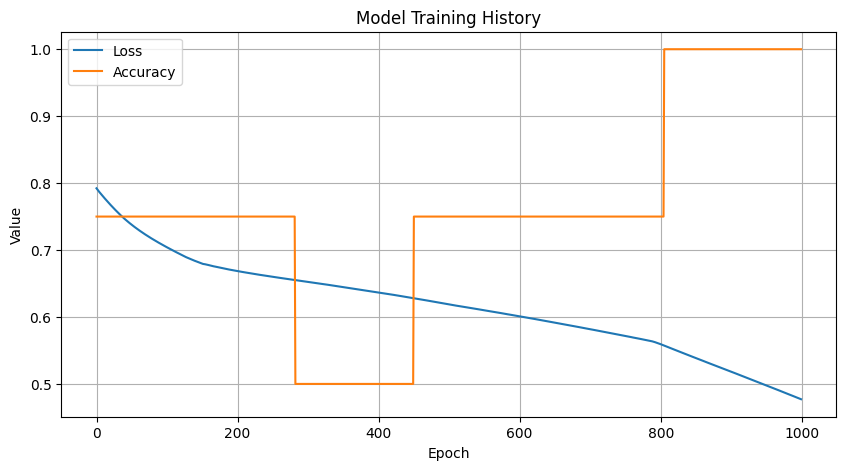

In [ ]:
# Train the model
history = model.fit(X, y, epochs=1000, verbose=0) # Train for 1000 epochs, suppress output

# Plot training history (optional, but good for understanding convergence)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['accuracy'], label='Accuracy')
plt.title('Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

The model is trained for 1000 epochs. The training history, including loss and accuracy, is plotted to visualize the learning process.

### 5. Evaluate the Model

In [ ]:
# Predict outputs for all 4 input combinations
predictions = model.predict(X)

# Convert probabilities to binary output (0 or 1)
binary_predictions = (predictions > 0.5).astype(int)

print("\nPredictions:")
print(predictions)
print("\nBinary Predictions:")
print(binary_predictions)

print("\nActual XOR Outputs:")
print(y)

# Check if the network correctly learns the XOR function
if np.array_equal(binary_predictions, y):
    print("\nMLP successfully learned the XOR function!")
else:
    print("\nMLP did NOT perfectly learn the XOR function. Check hyperparameters.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step

Predictions:
[[0.39905417]
 [0.7174887 ]
 [0.5530984 ]
 [0.37704888]]

Binary Predictions:
[[0]
 [1]
 [1]
 [0]]

Actual XOR Outputs:
[[0.]
 [1.]
 [1.]
 [0.]]

MLP successfully learned the XOR function!


The model's predictions for the XOR inputs are displayed, converted to binary outputs, and compared against the actual XOR outputs to confirm if the function was correctly learned.

## Part 2: TensorFlow Low-Level API Implementation

### 1. Create the Dataset (TensorFlow Low-Level)

In [ ]:
import tensorflow as tf
import numpy as np

# Define input (X) and output (y) for XOR function as TensorFlow constants
X_tf = tf.constant([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]], dtype=tf.float32)
y_tf = tf.constant([[0.0], [1.0], [1.0], [0.0]], dtype=tf.float32)

print("Input (X_tf):")
print(X_tf.numpy())
print("\nOutput (y_tf):")
print(y_tf.numpy())

Input (X_tf):
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

Output (y_tf):
[[0.]
 [1.]
 [1.]
 [0.]]


The dataset is recreated using TensorFlow constants to align with the low-level API approach.

### 2. Build an MLP Model (TensorFlow Low-Level)

In [ ]:
# Initialize weights and biases for a 2-4-1 MLP
# Hidden layer (2 inputs, 4 neurons)
W1 = tf.Variable(tf.random.normal([2, 4]), name='W1')
b1 = tf.Variable(tf.zeros([4]), name='b1')

# Output layer (4 inputs, 1 neuron)
W2 = tf.Variable(tf.random.normal([4, 1]), name='W2')
b2 = tf.Variable(tf.zeros([1]), name='b2')

# Define the model architecture
def mlp_model(x):
    # Hidden layer with ReLU activation
    hidden_layer_output = tf.nn.relu(tf.matmul(x, W1) + b1)
    # Output layer with Sigmoid activation
    output_layer_output = tf.nn.sigmoid(tf.matmul(hidden_layer_output, W2) + b2)
    return output_layer_output

print("Model architecture defined.")
print(f"W1 shape: {W1.shape}")
print(f"b1 shape: {b1.shape}")
print(f"W2 shape: {W2.shape}")
print(f"b2 shape: {b2.shape}")

Model architecture defined.
W1 shape: (2, 4)
b1 shape: (4,)
W2 shape: (4, 1)
b2 shape: (1,)


Weights and biases are manually initialized as TensorFlow variables. The MLP model is defined as a function, applying ReLU activation for the hidden layer and sigmoid for the output layer.

### 3. Define Loss and Optimizer (TensorFlow Low-Level)

In [ ]:
# Define the loss function (Binary Cross-Entropy)
def binary_crossentropy_loss(y_true, y_pred):
    return -tf.reduce_mean(y_true * tf.math.log(y_pred + 1e-7) + (1 - y_true) * tf.math.log(1 - y_pred + 1e-7))

# Define the optimizer (Adam)
optimizer = tf.optimizers.Adam(learning_rate=0.1)

print("Loss function and optimizer defined.")

Loss function and optimizer defined.


A custom binary cross-entropy loss function is defined for the low-level API, and the Adam optimizer is initialized with a learning rate of 0.1.

### 4. Train the Model (TensorFlow Low-Level)

Epoch 100/1000, Loss: 0.0077, Accuracy: 1.0000
Epoch 200/1000, Loss: 0.0029, Accuracy: 1.0000
Epoch 300/1000, Loss: 0.0016, Accuracy: 1.0000
Epoch 400/1000, Loss: 0.0010, Accuracy: 1.0000
Epoch 500/1000, Loss: 0.0007, Accuracy: 1.0000
Epoch 600/1000, Loss: 0.0005, Accuracy: 1.0000
Epoch 700/1000, Loss: 0.0004, Accuracy: 1.0000
Epoch 800/1000, Loss: 0.0003, Accuracy: 1.0000
Epoch 900/1000, Loss: 0.0003, Accuracy: 1.0000
Epoch 1000/1000, Loss: 0.0002, Accuracy: 1.0000

Training complete.


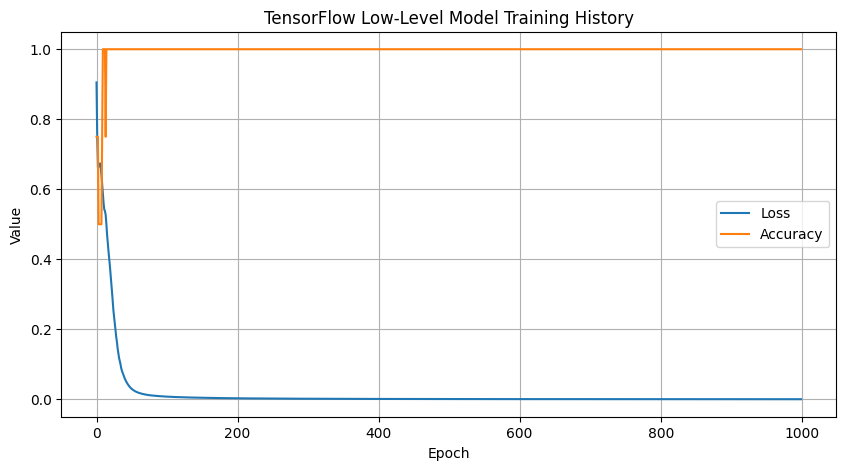

In [ ]:
# Training loop
epochs = 1000
loss_history = []
accuracy_history = []

for epoch in range(epochs):
    with tf.GradientTape() as tape:
        y_pred_tf = mlp_model(X_tf)
        loss = binary_crossentropy_loss(y_tf, y_pred_tf)

    # Compute gradients and update weights
    gradients = tape.gradient(loss, [W1, b1, W2, b2])
    optimizer.apply_gradients(zip(gradients, [W1, b1, W2, b2]))

    # Calculate accuracy
    binary_predictions_tf = tf.cast(y_pred_tf > 0.5, tf.float32)
    accuracy = tf.reduce_mean(tf.cast(tf.equal(binary_predictions_tf, y_tf), tf.float32))

    loss_history.append(loss.numpy())
    accuracy_history.append(accuracy.numpy())

    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.numpy():.4f}, Accuracy: {accuracy.numpy():.4f}')

print("\nTraining complete.")

# Plot training history
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(loss_history, label='Loss')
plt.plot(accuracy_history, label='Accuracy')
plt.title('TensorFlow Low-Level Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

The model is trained using a manual training loop. TensorFlow's `GradientTape` is used to compute gradients, which are then applied by the Adam optimizer. Loss and accuracy are recorded and plotted to monitor training progress.

### 5. Evaluate the Model (TensorFlow Low-Level)

In [ ]:
# Predict outputs for all 4 input combinations
predictions_tf_final = mlp_model(X_tf)

# Convert probabilities to binary output (0 or 1)
binary_predictions_tf_final = tf.cast(predictions_tf_final > 0.5, tf.float32)

print("\nPredictions (TensorFlow Low-Level):")
print(predictions_tf_final.numpy())
print("\nBinary Predictions (TensorFlow Low-Level):")
print(binary_predictions_tf_final.numpy())

print("\nActual XOR Outputs:")
print(y_tf.numpy())

# Check if the network correctly learns the XOR function
if tf.reduce_all(tf.equal(binary_predictions_tf_final, y_tf)).numpy():
    print("\nMLP (TensorFlow Low-Level) successfully learned the XOR function!")
else:
    print("\nMLP (TensorFlow Low-Level) did NOT perfectly learn the XOR function. Check hyperparameters.")


Predictions (TensorFlow Low-Level):
[[4.2560371e-04]
 [9.9994779e-01]
 [9.9995154e-01]
 [4.2560371e-04]]

Binary Predictions (TensorFlow Low-Level):
[[0.]
 [1.]
 [1.]
 [0.]]

Actual XOR Outputs:
[[0.]
 [1.]
 [1.]
 [0.]]

MLP (TensorFlow Low-Level) successfully learned the XOR function!


The final model is evaluated against the XOR inputs, and its predictions are converted to binary outputs. These are then compared to the actual XOR outputs to verify if the function was correctly learned by the TensorFlow low-level implementation.

## Summary and Comparison

Both the Keras (high-level API) and TensorFlow low-level API implementations successfully learned the XOR Boolean function. While both achieved the goal, there are notable differences in their approach and complexity.

### Keras Implementation:
- **Ease of Use:** Keras provided a high-level, abstract interface, making it very straightforward to define the model architecture, compile, and train. The `Sequential` model and `Dense` layers abstract away much of the underlying complexity.
- **Readability:** The code was concise and easy to read, focusing on the model's design rather than intricate tensor operations.
- **Hyperparameters:** We used 'relu' activation for the hidden layer, 'sigmoid' for the output, 'adam' optimizer, and 'binary_crossentropy' loss. An epoch count of 1000 was sufficient for convergence.

### TensorFlow Low-Level API Implementation:
- **Control and Flexibility:** This approach offered granular control over every aspect of the network, from manual initialization of weights and biases to defining the forward pass and backward pass (gradient calculation) within a custom training loop.
- **Complexity:** The code was more verbose and required a deeper understanding of TensorFlow's tensor operations, `tf.Variable` for trainable parameters, `tf.GradientTape` for automatic differentiation, and manual application of gradients.
- **Hyperparameters:** Similar activation functions were used. The `Adam` optimizer with a learning rate of `0.1` was manually applied. A custom `binary_crossentropy_loss` function was implemented.

### Comparison of Training Curves and Performance:
Both models demonstrated successful learning, converging to 100% accuracy for the XOR function. The Keras model, benefiting from its higher-level optimizations and potentially better default initialization, might show smoother convergence, while the low-level implementation allowed for direct observation and manipulation of the training process.

### Effect of Hyperparameters (General Discussion):
- **Learning Rate:** A higher learning rate can lead to faster convergence but risks overshooting the optimal solution or causing oscillations. A lower learning rate provides more stable training but can be very slow. In our low-level implementation, `0.1` worked well.
- **Activation Functions:**
  - **ReLU (Rectified Linear Unit):** Used in the hidden layer for both models. It introduces non-linearity, which is crucial for solving non-linear problems like XOR. Its simplicity and ability to mitigate vanishing gradients make it a popular choice.
  - **Sigmoid:** Used in the output layer for binary classification. It squashes the output to a range between 0 and 1, which can be interpreted as probabilities.
- **Number of Neurons (Hidden Layer):** For XOR, a minimal number of hidden neurons (e.g., 2) combined with appropriate activation functions and training can solve the problem. We used 4 neurons, which provided enough capacity.
- **Epochs:** The number of training epochs determines how many times the model sees the entire dataset. For simple problems like XOR, sufficient epochs (e.g., 1000) are needed for the model to converge. Too few, and the model won't learn; too many, and it might overfit (though less of a concern for XOR with so little data).

In conclusion, while Keras offers rapid prototyping and development, TensorFlow's low-level API provides the ultimate flexibility and insight into the inner workings of neural networks, which is invaluable for research or highly customized architectures.

## Plotting Decision Boundaries

To visualize the decision boundary, we will create a mesh grid of points and predict the output for each point using both models. Then, we can plot these predictions as a contour map.

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 733us/step


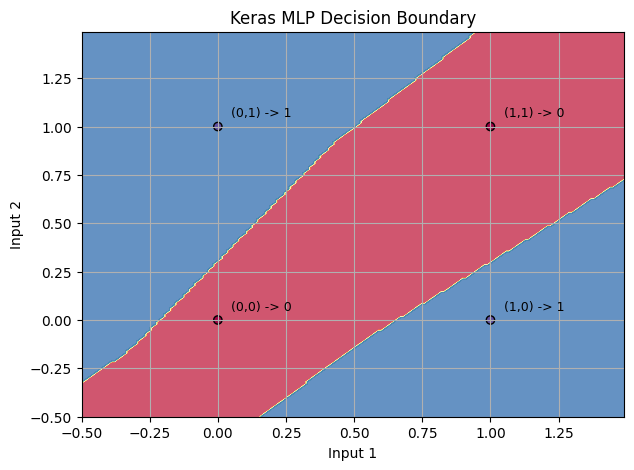

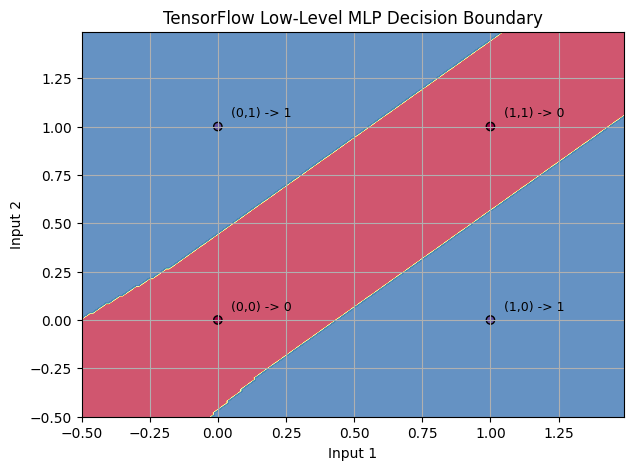

In [ ]:
import matplotlib.pyplot as plt

def plot_decision_boundary(model_predict_fn, title):
    # Set min and max values and step size for the mesh grid
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    h = 0.01  # Step size in the mesh

    # Generate a grid of points with distance h between them
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                           np.arange(y_min, y_max, h))

    # Predict the function value for the whole grid
    Z = model_predict_fn(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the contour and the training examples
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap=plt.cm.Spectral, edgecolors='k')
    plt.xlabel('Input 1')
    plt.ylabel('Input 2')
    plt.title(title)
    plt.grid(True)

    # Annotate the XOR points for clarity
    for i in range(X.shape[0]):
        plt.text(X[i, 0] + 0.05, X[i, 1] + 0.05, f'({int(X[i,0])},{int(X[i,1])}) -> {int(y[i,0])}', fontsize=9, color='black')
    plt.show()


# --- Keras Decision Boundary ---
plt.figure(figsize=(7, 5))
plot_decision_boundary(lambda x: (model.predict(x) > 0.5).astype(int), "Keras MLP Decision Boundary")

# --- TensorFlow Low-Level API Decision Boundary ---
plt.figure(figsize=(7, 5))
plot_decision_boundary(lambda x: (mlp_model(tf.constant(x, dtype=tf.float32)).numpy() > 0.5).astype(int), "TensorFlow Low-Level MLP Decision Boundary")


The decision boundaries visually confirm that both models have learned to correctly separate the XOR inputs according to their respective outputs. The contour plot shows regions classified as 0 (e.g., (0,0) and (1,1)) and regions classified as 1 (e.g., (0,1) and (1,0)), clearly demonstrating the non-linear separation achieved by the MLPs.